# BUSI Task 5: DenseNet121 Grad-CAM Setup
This notebook uses the trained DenseNet121 model to generate Grad-CAM visualizations for the BUSI test set. Grad-CAM highlights image regions that contributed most to the model's benign or malignant predictions. The method is first tested on individual examples and then applied to all 130 test images.

## Import Libraries
Import the libraries required to load the BUSI metadata, preprocess images, recreate DenseNet121, and load its trained weights.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

## Configuration and Reproducibility
Reuse the device, random seed, test path, image size, batch size, and label mapping from the completed BUSI classification workflow.

In [2]:
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset_dir = Path('/data/barbanp/datasets/BUSI')
image_folder = dataset_dir / 'images-20260621T231610Z-3-001' / 'images'
test_path = dataset_dir / 'test.xlsx'
model_weights_path = Path('/data/barbanp/research_training/models/densenet121_busi.pth')

label_names = {1: 'benign', 0: 'malignant'}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## BUSI Test Dataset
Reuse the same dataset class and predefined BUSI test metadata used by the completed DenseNet121 and ROC notebooks. Images are converted to RGB before preprocessing.

In [3]:
class BUSIDataset(Dataset):
    """PyTorch dataset for BUSI image filenames and binary labels."""

    def __init__(self, dataframe, image_folder, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_folder = Path(image_folder)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = self.image_folder / str(row['Image'])

        if not image_path.is_file():
            raise FileNotFoundError(f'Image file not found: {image_path}')

        with Image.open(image_path) as image:
            image = image.convert('RGB')
            if self.transform is not None:
                image = self.transform(image)

        label = torch.tensor(int(row['Label']), dtype=torch.long)
        return image, label

## Image Transforms and Test DataLoader
Apply the exact 224×224 resize, tensor conversion, and ImageNet normalization used during DenseNet121 training. The test loader preserves metadata order with `shuffle=False`.

In [4]:
image_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_df = pd.read_excel(test_path)
test_dataset = BUSIDataset(
    dataframe=test_df,
    image_folder=image_folder,
    transform=image_transforms
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## Recreate DenseNet121 and Load Trained Weights
Recreate the exact two-class DenseNet121 architecture used during training without downloading ImageNet weights, then load the saved trained state dictionary.

In [5]:
densenet121_model = models.densenet121(weights=None)
num_features = densenet121_model.classifier.in_features
densenet121_model.classifier = nn.Linear(num_features, 2)

densenet121_model.load_state_dict(torch.load(
    model_weights_path,
    map_location=device,
    weights_only=True
))
densenet121_model = densenet121_model.to(device)
densenet121_model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

## Setup Confirmation
Print basic information confirming that the test data and trained DenseNet121 are ready for the later CAM implementation.

In [6]:
print(f'Using device: {device}')
print(f'Number of test images: {len(test_dataset)}')
print(f'Label mapping: {label_names}')
print(f'DenseNet121 weights loaded successfully from: {model_weights_path}')
print(f'Model evaluation mode: {not densenet121_model.training}')

Using device: cuda
Number of test images: 130
Label mapping: {1: 'benign', 0: 'malignant'}
DenseNet121 weights loaded successfully from: /data/barbanp/research_training/models/densenet121_busi.pth
Model evaluation mode: True


## Single-Image Grad-CAM Test
Test the Grad-CAM process on one image from the existing BUSI test dataset before extending it to multiple images. This section captures activations and class-specific gradients from `model.features.norm5`, displays the normalized heatmap, and does not save any images.

Ground-truth label: malignant
Predicted label: malignant
Predicted class probabilities: {'malignant': 0.9897282719612122, 'benign': 0.01027180626988411}
Grad-CAM range: 0.0000 to 0.9938


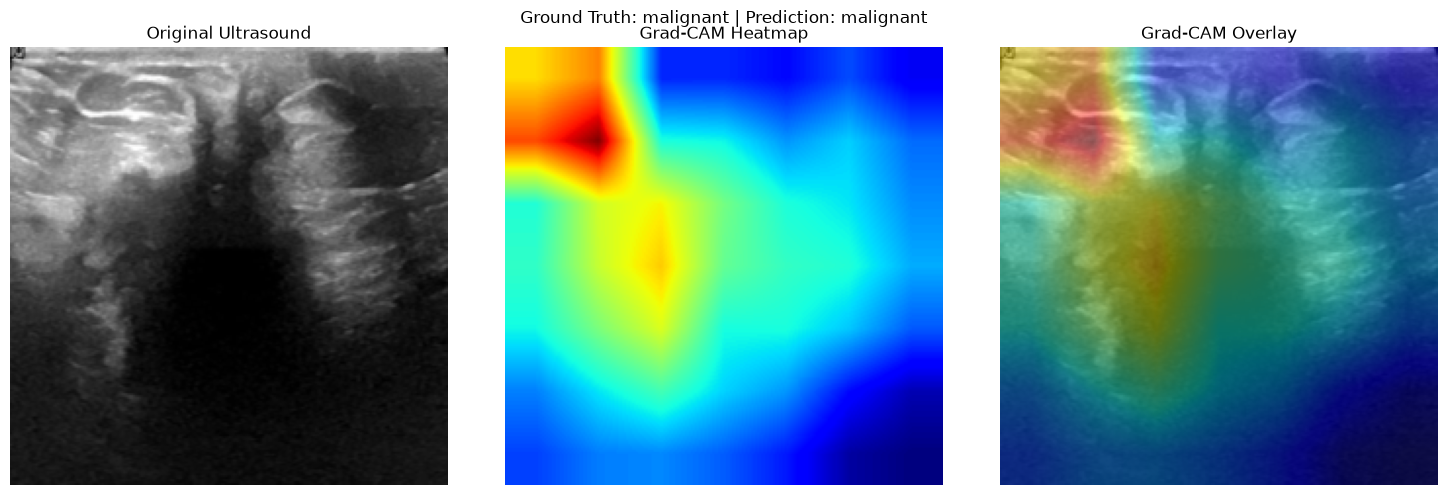

In [9]:
# Capture the target-layer activation and its class-specific gradient.
activations = {}
gradients = {}


def save_gradient(gradient):
    gradients['value'] = gradient.detach()


def save_activation(module, module_input, module_output):
    activations['value'] = module_output.detach()
    module_output.register_hook(save_gradient)


# Use one test image for the initial Grad-CAM check.
target_layer = densenet121_model.features.norm5
target_layer_handle = target_layer.register_forward_hook(save_activation)
image_tensor, ground_truth_tensor = test_dataset[0]
input_tensor = image_tensor.unsqueeze(0).to(device)
ground_truth_label = ground_truth_tensor.item()

# Run one forward pass and backpropagate the score for the predicted class.
densenet121_model.zero_grad(set_to_none=True)
outputs = densenet121_model(input_tensor)
probabilities = torch.softmax(outputs, dim=1)[0]
predicted_label = outputs.argmax(dim=1).item()
selected_class_score = outputs[0, predicted_label]
selected_class_score.backward()
target_layer_handle.remove()

# Compute and normalize the Grad-CAM map.
activation_maps = activations['value']
gradient_maps = gradients['value']
channel_weights = gradient_maps.mean(dim=(2, 3), keepdim=True)
grad_cam = torch.relu((channel_weights * activation_maps).sum(dim=1, keepdim=True))

cam_min = grad_cam.min()
cam_max = grad_cam.max()
if (cam_max - cam_min).item() > 0:
    grad_cam = (grad_cam - cam_min) / (cam_max - cam_min)
else:
    grad_cam = torch.zeros_like(grad_cam)

# Undo ImageNet normalization for display and resize the heatmap to the image size.
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
original_image = image_tensor.cpu() * imagenet_std + imagenet_mean
original_image = original_image.clamp(0, 1).permute(1, 2, 0).numpy()

grad_cam = F.interpolate(
    grad_cam,
    size=original_image.shape[:2],
    mode='bilinear',
    align_corners=False
)
heatmap = grad_cam.squeeze().cpu().numpy()

class_probabilities = {
    label_names[class_index]: float(probabilities[class_index].detach().cpu())
    for class_index in sorted(label_names)
}
print(f'Ground-truth label: {label_names[ground_truth_label]}')
print(f'Predicted label: {label_names[predicted_label]}')
print(f'Predicted class probabilities: {class_probabilities}')
print(f'Grad-CAM range: {heatmap.min():.4f} to {heatmap.max():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_image)
axes[0].set_title('Original Ultrasound')
axes[1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
axes[1].set_title('Grad-CAM Heatmap')
axes[2].imshow(original_image)
axes[2].imshow(heatmap, cmap='jet', alpha=0.45, vmin=0, vmax=1)
axes[2].set_title('Grad-CAM Overlay')

for axis in axes:
    axis.axis('off')

fig.suptitle(
    f"Ground Truth: {label_names[ground_truth_label]} | "
    f"Prediction: {label_names[predicted_label]}"
)
plt.tight_layout()
plt.show()

## Multi-Image Grad-CAM Validation
Check whether the Grad-CAM behavior is consistent across both malignant and benign ground-truth classes using a small six-image validation set. The visualizations are displayed only and are not saved.

Image 0: ground truth = malignant, prediction = malignant, confidence = 0.9897


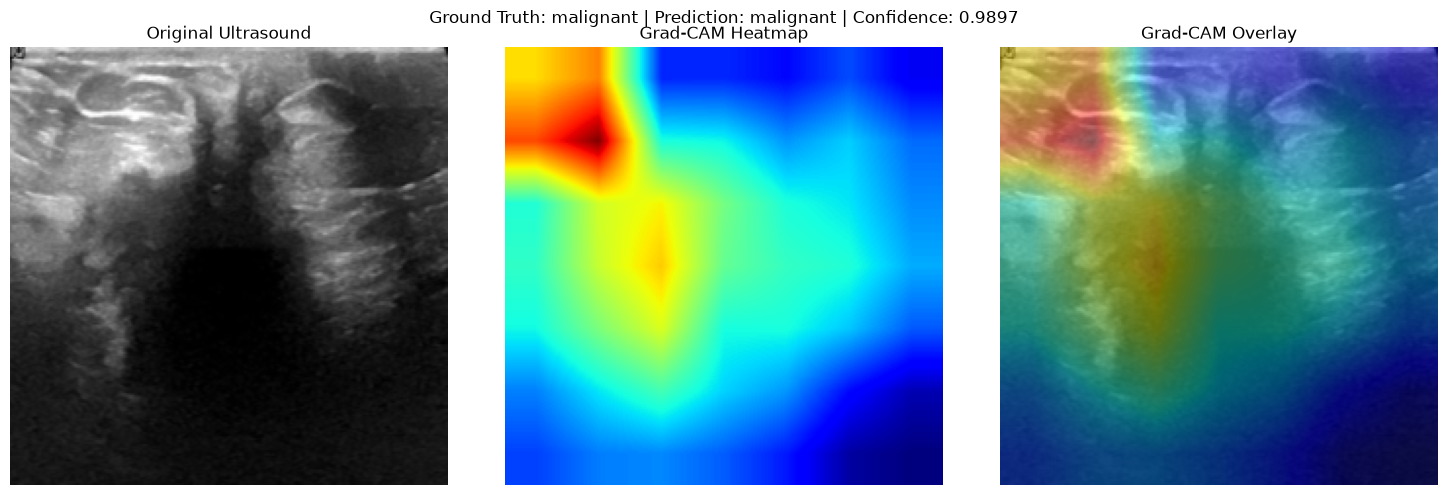

Image 5: ground truth = malignant, prediction = malignant, confidence = 0.9957


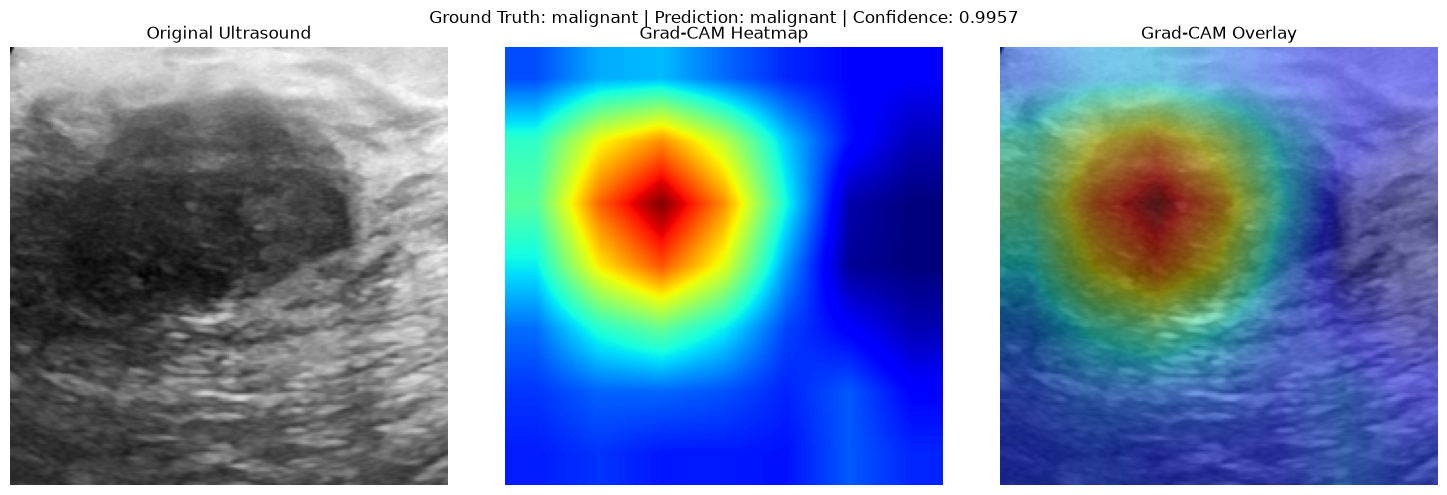

Image 10: ground truth = malignant, prediction = malignant, confidence = 0.9846


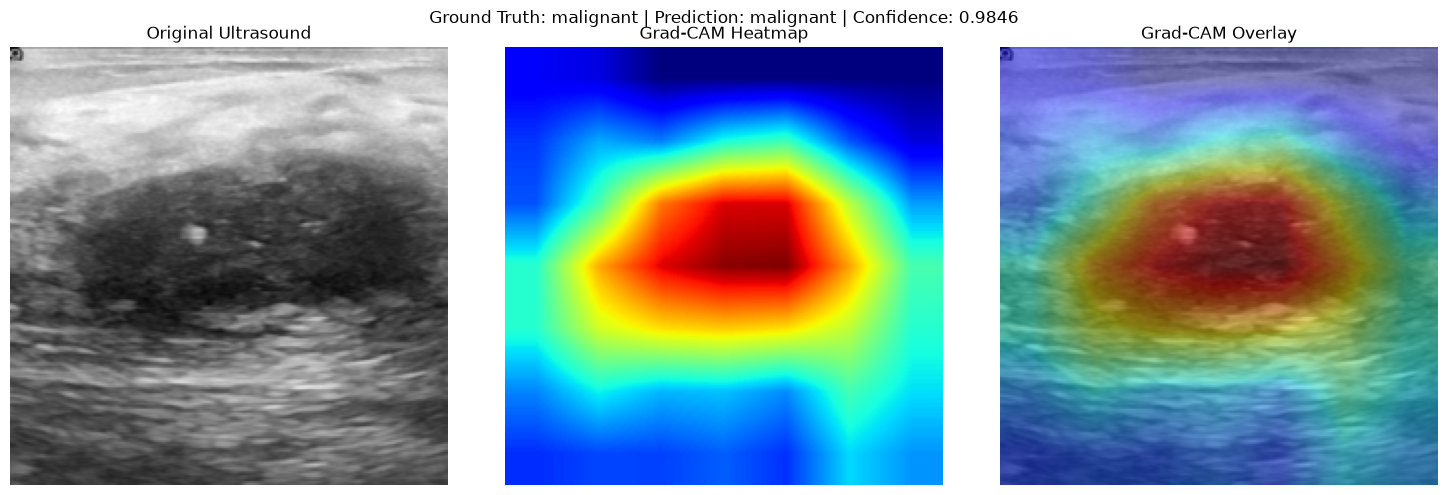

Image 1: ground truth = benign, prediction = benign, confidence = 0.9984


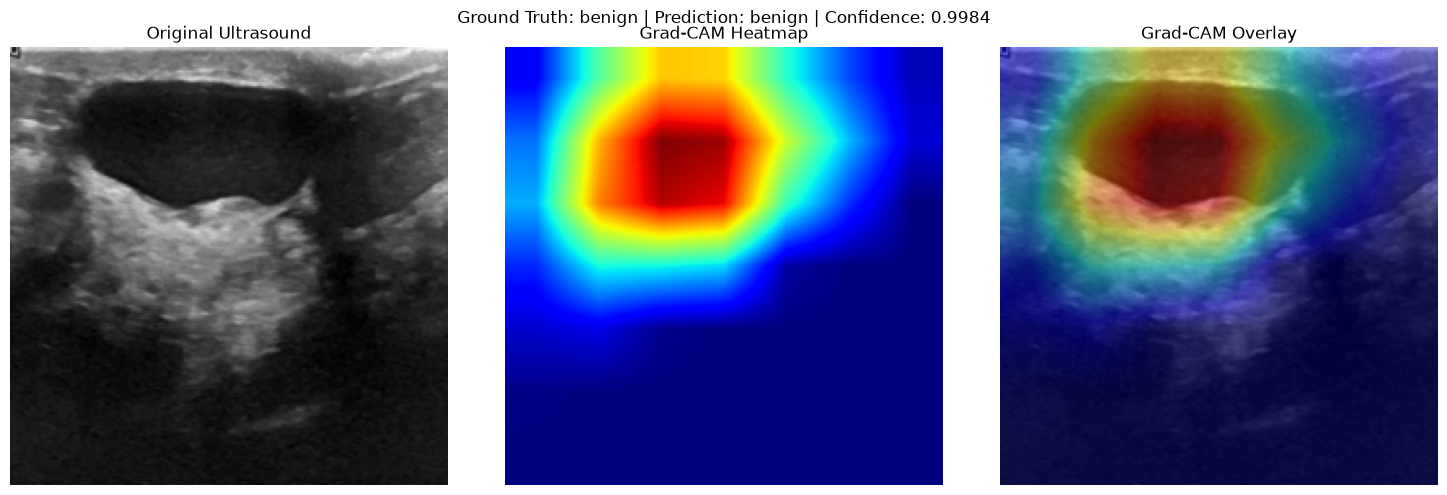

Image 2: ground truth = benign, prediction = benign, confidence = 0.9777


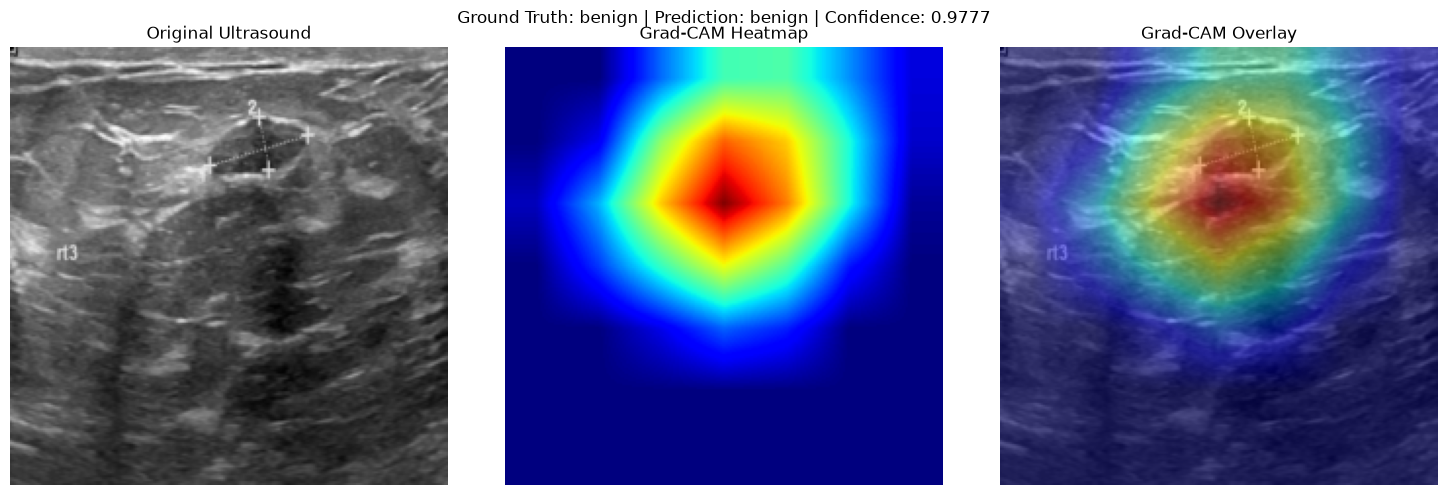

Image 3: ground truth = benign, prediction = benign, confidence = 0.9997


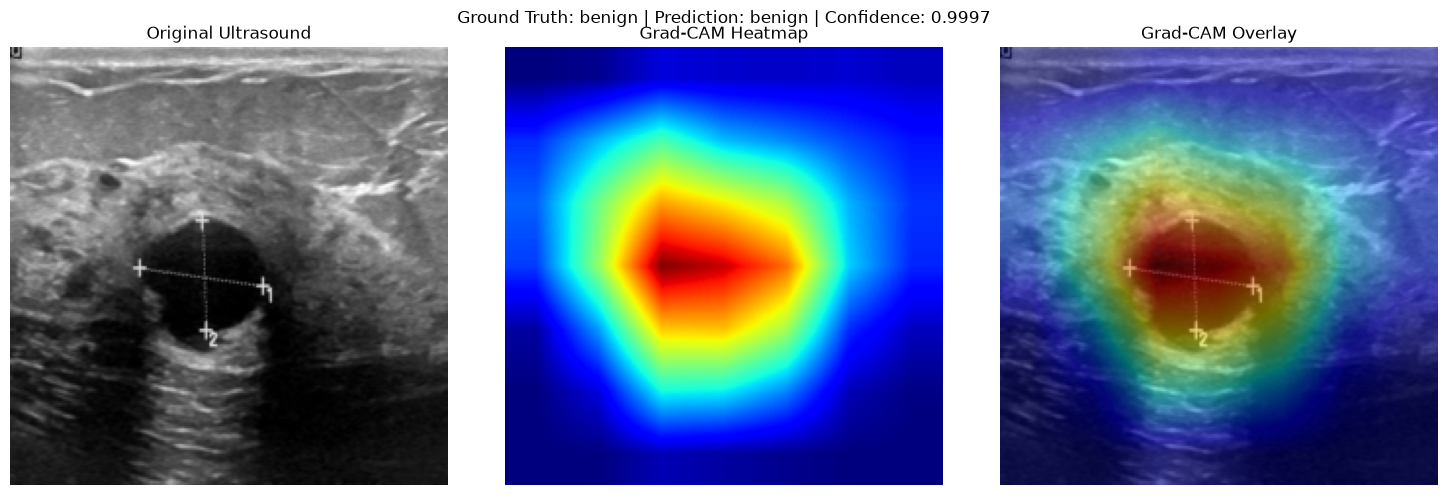

In [10]:
# Select three images from each ground-truth class without scanning the full dataset.
malignant_indices = test_df.index[test_df['Label'] == 0].tolist()[:3]
benign_indices = test_df.index[test_df['Label'] == 1].tolist()[:3]
validation_indices = malignant_indices + benign_indices

for image_index in validation_indices:
    activations = {}
    gradients = {}

    def save_validation_gradient(gradient):
        gradients['value'] = gradient.detach()

    def save_validation_activation(module, module_input, module_output):
        activations['value'] = module_output.detach()
        module_output.register_hook(save_validation_gradient)

    target_layer = densenet121_model.features.norm5
    target_layer_handle = target_layer.register_forward_hook(save_validation_activation)
    image_tensor, ground_truth_tensor = test_dataset[image_index]
    input_tensor = image_tensor.unsqueeze(0).to(device)
    ground_truth_label = ground_truth_tensor.item()

    try:
        densenet121_model.zero_grad(set_to_none=True)
        outputs = densenet121_model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_label = outputs.argmax(dim=1).item()
        predicted_confidence = float(probabilities[predicted_label].detach().cpu())
        outputs[0, predicted_label].backward()
    finally:
        target_layer_handle.remove()

    activation_maps = activations['value']
    gradient_maps = gradients['value']
    channel_weights = gradient_maps.mean(dim=(2, 3), keepdim=True)
    grad_cam = torch.relu((channel_weights * activation_maps).sum(dim=1, keepdim=True))

    cam_min = grad_cam.min()
    cam_max = grad_cam.max()
    if (cam_max - cam_min).item() > 0:
        grad_cam = (grad_cam - cam_min) / (cam_max - cam_min)
    else:
        grad_cam = torch.zeros_like(grad_cam)

    original_image = image_tensor.cpu() * imagenet_std + imagenet_mean
    original_image = original_image.clamp(0, 1).permute(1, 2, 0).numpy()
    grad_cam = F.interpolate(
        grad_cam,
        size=original_image.shape[:2],
        mode='bilinear',
        align_corners=False
    )
    heatmap = grad_cam.squeeze().cpu().numpy()

    print(
        f'Image {image_index}: '
        f'ground truth = {label_names[ground_truth_label]}, '
        f'prediction = {label_names[predicted_label]}, '
        f'confidence = {predicted_confidence:.4f}'
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original_image)
    axes[0].set_title('Original Ultrasound')
    axes[1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Grad-CAM Heatmap')
    axes[2].imshow(original_image)
    axes[2].imshow(heatmap, cmap='jet', alpha=0.45, vmin=0, vmax=1)
    axes[2].set_title('Grad-CAM Overlay')

    for axis in axes:
        axis.axis('off')

    fig.suptitle(
        f"Ground Truth: {label_names[ground_truth_label]} | "
        f"Prediction: {label_names[predicted_label]} | "
        f"Confidence: {predicted_confidence:.4f}"
    )
    plt.tight_layout()
    plt.show()

## Generate Grad-CAMs for the Complete Test Set
Apply the validated Grad-CAM method to all 130 BUSI test images for Task 5. Each three-panel visualization includes the original ultrasound, heatmap, overlay, ground-truth label, predicted label, and prediction confidence, and is saved in the project `cam_outputs` folder.

In [11]:
cam_output_dir = Path('/data/barbanp/research_training/cam_outputs')
cam_output_dir.mkdir(parents=True, exist_ok=True)


def generate_gradcam(image_index):
    """Generate one normalized Grad-CAM using the validated norm5 target layer."""
    activations = {}
    gradients = {}

    def save_gradient(gradient):
        gradients['value'] = gradient.detach()

    def save_activation(module, module_input, module_output):
        activations['value'] = module_output.detach()
        module_output.register_hook(save_gradient)

    target_layer = densenet121_model.features.norm5
    target_layer_handle = target_layer.register_forward_hook(save_activation)
    image_tensor, ground_truth_tensor = test_dataset[image_index]
    input_tensor = image_tensor.unsqueeze(0).to(device)
    ground_truth_label = ground_truth_tensor.item()

    try:
        densenet121_model.zero_grad(set_to_none=True)
        outputs = densenet121_model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_label = outputs.argmax(dim=1).item()
        predicted_confidence = float(probabilities[predicted_label].detach().cpu())
        outputs[0, predicted_label].backward()
    finally:
        target_layer_handle.remove()

    channel_weights = gradients['value'].mean(dim=(2, 3), keepdim=True)
    grad_cam = torch.relu(
        (channel_weights * activations['value']).sum(dim=1, keepdim=True)
    )
    cam_min = grad_cam.min()
    cam_max = grad_cam.max()
    if (cam_max - cam_min).item() > 0:
        grad_cam = (grad_cam - cam_min) / (cam_max - cam_min)
    else:
        grad_cam = torch.zeros_like(grad_cam)

    original_image = image_tensor.cpu() * imagenet_std + imagenet_mean
    original_image = original_image.clamp(0, 1).permute(1, 2, 0).numpy()
    heatmap = F.interpolate(
        grad_cam,
        size=original_image.shape[:2],
        mode='bilinear',
        align_corners=False
    ).squeeze().cpu().numpy()

    return (
        original_image,
        heatmap,
        ground_truth_label,
        predicted_label,
        predicted_confidence,
    )


saved_cam_paths = []
densenet121_model.eval()

for image_index in range(len(test_dataset)):
    (
        original_image,
        heatmap,
        ground_truth_label,
        predicted_label,
        predicted_confidence,
    ) = generate_gradcam(image_index)

    source_filename = Path(str(test_df.iloc[image_index]['Image'])).name
    source_path = Path(source_filename)
    output_filename = f'{source_path.stem}_gradcam{source_path.suffix or ".png"}'
    output_path = cam_output_dir / output_filename

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original_image)
    axes[0].set_title('Original Ultrasound')
    axes[1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Grad-CAM Heatmap')
    axes[2].imshow(original_image)
    axes[2].imshow(heatmap, cmap='jet', alpha=0.45, vmin=0, vmax=1)
    axes[2].set_title('Grad-CAM Overlay')

    for axis in axes:
        axis.axis('off')

    fig.suptitle(
        f"Ground Truth: {label_names[ground_truth_label]} | "
        f"Prediction: {label_names[predicted_label]} | "
        f"Confidence: {predicted_confidence:.4f}"
    )
    fig.tight_layout()
    fig.savefig(output_path, bbox_inches='tight')
    plt.close(fig)
    saved_cam_paths.append(output_path)

saved_cam_files = sorted(cam_output_dir.glob('*_gradcam.png'))
assert len(saved_cam_paths) == len(test_dataset) == 130
assert len(saved_cam_files) == 130

print(f'Test images processed: {len(test_dataset)}')
print(f'Grad-CAM files saved: {len(saved_cam_files)}')
print(f'Output folder: {cam_output_dir}')

Test images processed: 130
Grad-CAM files saved: 130
Output folder: /data/barbanp/research_training/cam_outputs
